In [1]:
!pip install tensorflow

In [2]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Conv2D, Dense, Flatten, Dropout
from tensorflow.keras.models import Model

In [3]:
cifar = tf.keras.datasets.cifar10

In [4]:
(x_train,y_train),(x_test,y_test) = cifar.load_data()
# carrega o dataset
x_train,x_test = x_train /255.0,x_test / 255.0
#normaliza para 0-1
y_train,y_test = y_train.flatten(), y_test.flatten()
# vetoriza as classes
print(x_train.shape)
print(y_train.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1973s 12us/step
(50000, 32, 32, 3)
(50000,)


In [5]:
K = len(set(y_train))
# pega quantas classes o datset tem
print('classes: ', K)

classes:  10


In [6]:
i =Input(shape=x_train[0].shape)
x = Conv2D(32, (3,3),strides=2,activation='relu')(i)
x=Conv2D(64,(3,3), strides=2,activation='relu')(x)
x=Conv2D(128,(3,3), strides=2,activation='relu')(x)
x=Flatten()(x)
x=Dropout(rate=0.2)(x)
x=Dense(1024,activation='relu')(x)
x=Dropout(rate=0.2)(x)
x=Dense(K,activation='softmax')(x)
# mesma rede do arquivo anterior
model=Model(i,x)

In [7]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
r=model.fit(x_train,y_train,validation_data=(x_test,y_test),epochs=15)

Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 54s 33ms/step - accuracy: 0.4448 - loss: 1.5280 - val_accuracy: 0.5482 - val_loss: 1.2376
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 50s 32ms/step - accuracy: 0.5731 - loss: 1.1886 - val_accuracy: 0.6039 - val_loss: 1.1182
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 51s 33ms/step - accuracy: 0.6362 - loss: 1.0175 - val_accuracy: 0.6595 - val_loss: 0.9692
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 50s 32ms/step - accuracy: 0.6804 - loss: 0.9030 - val_accuracy: 0.6697 - val_loss: 0.9407
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 32ms/step - accuracy: 0.7148 - loss: 0.8039 - val_accuracy: 0.6808 - val_loss: 0.9171
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 49s 31ms/step - accuracy: 0.7448 - loss: 0.7244 - val_accuracy: 0.6805 - val_loss: 0.9150
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 31ms/step - accuracy: 0.7695 - loss: 0.6509 - val_accuracy: 0.6959 - val_loss: 0.8945
Epoch 8/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 51s 33ms/step - accuracy: 0.7956 -

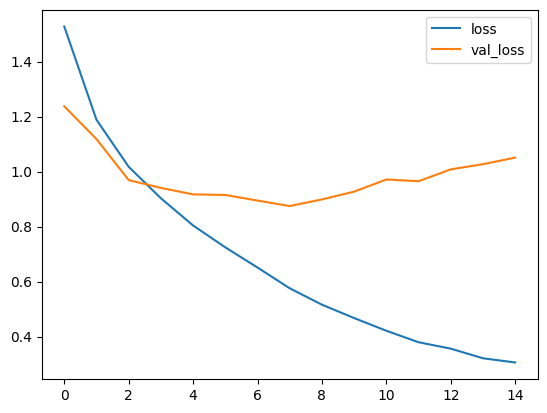

In [8]:
plt.plot(r.history['loss'],label='loss')
plt.plot(r.history['val_loss'],label='val_loss')
plt.legend()
# uma acuracia muito baixa, é muito claro visto os treinos que a rede sofreu overfitting

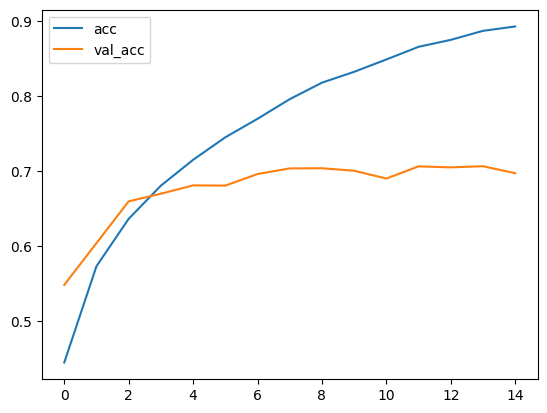

In [9]:
plt.plot(r.history['accuracy'],label='acc')
plt.plot(r.history['val_accuracy'],label='val_acc')
plt.legend()

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


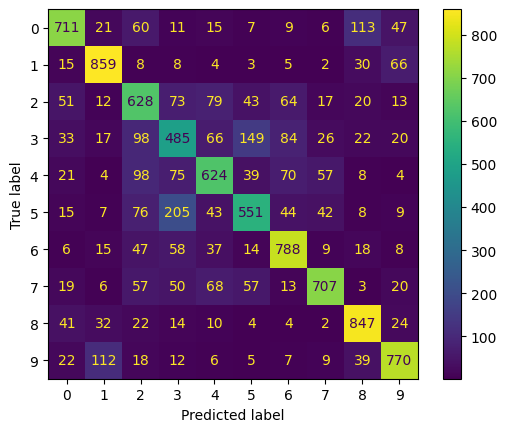

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
y_pred = model.predict(x_test).argmax(axis=1)
cm = confusion_matrix(y_test, y_pred)
# podemos

matrix = ConfusionMatrixDisplay(confusion_matrix=cm)
matrix.plot()
plt.show()